# KLRfome synthetic methods laboratory

This notebook is a guided diagnostic for the M0–M4 methods and representation extensions, not a model-ranking contest. It has five modes:

- **smoke** runs one easy case to validate execution, metrics, M1 approximation diagnostics, and invariance checks.
- **core** runs 64 controlled cases to test null behavior, signal recovery, bag-size sensitivity, spatial dependence, and unequal bags.
- **targeted_v2** revisits unresolved questions with pooled out-of-fold metrics, weaker nuisance signals, greater replication, corrected spatial dependence, and a moment-matched nonlinear test.
- **extensions_smoke** validates IID versus orthogonal random features, shrinkage embeddings, population-reference error, and the experimental M4 hybrid.
- **extensions** is the replicated research suite for deciding whether those extensions merit empirical validation.
- **spatial_shrinkage** is the focused follow-up for coordinate-based effective sample size and cached ORF construction.

The unit of scientific replication is an independently generated synthetic case. Cross-validation folds within a case are averaged before uncertainty is calculated. Scores represent relative ranking, not occurrence probability.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from klrfome.utils.evaluation import replicate_summary

REPOSITORY = Path.cwd()
if not (REPOSITORY / 'benchmarks').exists():
    REPOSITORY = REPOSITORY.parent

# Change only this value when advancing from the diagnostic run to the research run.
LAB_MODE = 'spatial_shrinkage'  # smoke, core, targeted_v2, extensions_smoke, extensions, or spatial_shrinkage
RUN_EXPERIMENT = True

CONFIGURATIONS = {
    'smoke': REPOSITORY / 'benchmarks/synthetic_lab_smoke_config.json',
    'core': REPOSITORY / 'benchmarks/synthetic_lab_config.json',
    'targeted_v2': REPOSITORY / 'benchmarks/synthetic_lab_targeted_v2_config.json',
    'extensions_smoke': REPOSITORY / 'benchmarks/synthetic_lab_extensions_smoke_config.json',
    'extensions': REPOSITORY / 'benchmarks/synthetic_lab_extensions_config.json',
    'spatial_shrinkage': REPOSITORY / 'benchmarks/synthetic_lab_spatial_shrinkage_config.json',
}
OUTPUTS = {
    'smoke': REPOSITORY / 'benchmark_data/synthetic_lab_smoke_notebook_results.json',
    'core': REPOSITORY / 'benchmark_data/synthetic_lab_results.json',
    'targeted_v2': REPOSITORY / 'benchmark_data/synthetic_lab_targeted_v2_results.json',
    'extensions_smoke': REPOSITORY / 'benchmark_data/synthetic_lab_extensions_smoke_results.json',
    'extensions': REPOSITORY / 'benchmark_data/synthetic_lab_extensions_results.json',
    'spatial_shrinkage': REPOSITORY / 'benchmark_data/synthetic_lab_spatial_shrinkage_results.json',
}
if LAB_MODE not in CONFIGURATIONS:
    raise ValueError(f'Unknown LAB_MODE: {LAB_MODE}')
CONFIGURATION = CONFIGURATIONS[LAB_MODE]
OUTPUT = OUTPUTS[LAB_MODE]
sns.set_theme(style='whitegrid', context='notebook')

## 1. Configure, run, and verify scope

Keep RUN_EXPERIMENT set to True to regenerate the selected output. Set it to False to inspect an existing result without rerunning models. Every mode uses a separate output file.

In [2]:
def expand_case_metadata(configuration):
    """Reconstruct the runner's case order and preserve each experiment family."""
    records = []
    case_index = 0
    default_bag_size = int(configuration.get('bag_size', 30))
    default_replicates = int(configuration.get('replicates', 1))
    for block_index, block in enumerate(configuration['scenarios']):
        effects = block.get('effect_sizes', [block.get('effect_size', 0.75)])
        bag_sizes = block.get('bag_sizes', [block.get('bag_size', default_bag_size)])
        spatial_ranges = block.get('spatial_ranges', [block.get('spatial_range', 0.0)])
        replicates = int(block.get('replicates', default_replicates))
        if block['scenario'] == 'null':
            family = 'null_control'
        elif block.get('unequal_bag_sizes', False):
            family = 'unequal_bags'
        elif len(bag_sizes) > 1:
            family = 'bag_size_sensitivity'
        elif len(spatial_ranges) > 1:
            family = 'spatial_dependence'
        else:
            family = 'signal_recovery'
        for effect in effects:
            for bag_size in bag_sizes:
                for spatial_range in spatial_ranges:
                    for replicate in range(replicates):
                        records.append({
                            'case_index': case_index,
                            'scenario_block': block_index,
                            'experiment_family': family,
                            'replicate': replicate + 1,
                            'configured_scenario': block['scenario'],
                            'configured_effect_size': float(effect),
                            'configured_bag_size': int(bag_size),
                            'configured_spatial_range': float(spatial_range),
                            'configured_unequal_bags': bool(block.get('unequal_bag_sizes', False)),
                        })
                        case_index += 1
    return pd.DataFrame(records).set_index('case_index', drop=False)

configuration = json.loads(CONFIGURATION.read_text())
expected_cases = expand_case_metadata(configuration)
display(Markdown(
    f"**Selected mode: {LAB_MODE.upper()}**  \n"
    f"Configuration: {CONFIGURATION.name}  \n"
    f"Expanded cases: {len(expected_cases)}  \n"
    f"Output: {OUTPUT.relative_to(REPOSITORY)}"
))
if LAB_MODE in {'smoke', 'extensions_smoke'}:
    display(Markdown('**Interpretation boundary:** this run validates the pipeline only; it cannot rank methods.'))
else:
    display(Markdown('**Research run:** conclusions require replicate consistency and paired differences, not a single winning fold.'))

**Selected mode: SPATIAL_SHRINKAGE**  
Configuration: synthetic_lab_spatial_shrinkage_config.json  
Expanded cases: 40  
Output: benchmark_data/synthetic_lab_spatial_shrinkage_results.json

**Research run:** conclusions require replicate consistency and paired differences, not a single winning fold.

In [3]:
if RUN_EXPERIMENT:
    subprocess.run(
        [
            sys.executable,
            str(REPOSITORY / 'benchmarks/run_synthetic_methods_lab.py'),
            '--config', str(CONFIGURATION),
            '--output', str(OUTPUT),
        ],
        cwd=REPOSITORY,
        check=True,
    )

if not OUTPUT.exists():
    raise FileNotFoundError('Run the experiment or select an existing output file.')
result = json.loads(OUTPUT.read_text())
if result['configuration'] != configuration:
    raise ValueError('The result configuration does not match the selected configuration.')
print(result['configuration_sha256'])
print(f"{len(result['cases'])} cases loaded from {OUTPUT.name}")

starting synthetic case 1/40: null seed=3444837047
starting synthetic case 2/40: null seed=158699116
starting synthetic case 3/40: null seed=3650102318
starting synthetic case 4/40: null seed=1243879478
starting synthetic case 5/40: null seed=1896493428
starting synthetic case 6/40: null seed=1181600143
starting synthetic case 7/40: null seed=2886031247
starting synthetic case 8/40: null seed=1905503689
starting synthetic case 9/40: mean_shift seed=3329053876
starting synthetic case 10/40: mean_shift seed=1849681246
starting synthetic case 11/40: mean_shift seed=2821847582
starting synthetic case 12/40: mean_shift seed=3709421164
starting synthetic case 13/40: mean_shift seed=2134191843
starting synthetic case 14/40: mean_shift seed=607729454
starting synthetic case 15/40: mean_shift seed=3545464025
starting synthetic case 16/40: mean_shift seed=2376084213
starting synthetic case 17/40: mean_shift seed=2436437895
starting synthetic case 18/40: mean_shift seed=1128002042
starting synthe

## 2. What the metrics answer

| Metric | Question | Interpretation caution |
|---|---|---|
| ROC AUC | Are presence bags ranked above background bags? | 0.5 is chance; it ignores score calibration. |
| PR AUC | How concentrated are presences near the top of the ranking? | Its chance baseline depends on prevalence. |
| Boyce | Does observed presence frequency rise with suitability? | It is legitimately undefined when folds or score bins are too small. |
| Top-5% lift | How enriched is the highest-scoring fraction? | It becomes coarse or saturated with small test folds. |
| Score separation | How far apart are mean class scores? | Compare within a method; score scales differ across methods. |
| Train–test AUC gap | Is the model fitting training structure that does not generalize? | Positive values indicate possible overfitting. |
| Paired delta from M0 | Does a method beat the exact reference on identical cases and folds? | Require consistency across independent synthetic cases. |

In [4]:
metadata_by_index = expected_cases.to_dict(orient='index')
records = []
oof_records = []
for case in result['cases']:
    case_index = int(case['case_id'].split('-', 2)[1])
    metadata = metadata_by_index[case_index]
    scenario = case['scenario']
    for row in case['fold_results']:
        records.append({
            'case_id': case['case_id'],
            'case_index': case_index,
            'experiment_family': metadata['experiment_family'],
            'replicate': metadata['replicate'],
            'scenario': scenario['scenario'],
            'effect_size': float(scenario['effect_size']),
            'bag_size': int(scenario['bag_size']),
            'spatial_range': float(scenario['spatial_range']),
            'unequal_bag_sizes': bool(scenario['unequal_bag_sizes']),
            'seed': int(scenario['seed']),
            **row,
        })
    for row in case.get('out_of_fold_results', []):
        oof_records.append({
            'case_id': case['case_id'],
            'case_index': case_index,
            'experiment_family': metadata['experiment_family'],
            'replicate': metadata['replicate'],
            'scenario': scenario['scenario'],
            'effect_size': float(scenario['effect_size']),
            'bag_size': int(scenario['bag_size']),
            'spatial_range': float(scenario['spatial_range']),
            'unequal_bag_sizes': bool(scenario['unequal_bag_sizes']),
            'seed': int(scenario['seed']),
            **row,
        })
folds = pd.DataFrame(records)
oof = pd.DataFrame(oof_records)
if oof.empty:
    display(Markdown('**Legacy result:** pooled out-of-fold predictions are unavailable; fold means are used for compatibility.'))

method_order = [item.get('id', item['method']) for item in configuration['methods']]
if configuration.get('include_baselines', True):
    method_order.extend(['LR-mean', 'RF-mean'])
    if configuration.get('include_mean_std_baseline', True):
        method_order.append('LR-mean-std')
method_order = [method for method in method_order if method in set(folds['method'])]
palette = dict(zip(method_order, sns.color_palette('husl', n_colors=len(method_order))))
folds.head()

,case_id,case_index,experiment_family,replicate,scenario,effect_size,bag_size,spatial_range,unequal_bag_sizes,seed,...,method,n_test,n_train,peak_python_memory_mb,pr_auc,predict_seconds,repeat,score_separation,top_5_percent_lift,train_auc
0,case-0000-null,0,null_control,1,null,0.0,30,0.0,False,3444837047,...,M0,12,36,2.140497,0.944444,0.426754,1,0.063399,2.0,0.802469
1,case-0000-null,0,null_control,1,null,0.0,30,0.0,False,3444837047,...,M1-iid128,12,36,1.998294,0.944444,0.150658,1,0.055811,2.0,0.808642
2,case-0000-null,0,null_control,1,null,0.0,30,0.0,False,3444837047,...,M1-orf128,12,36,1.330027,0.944444,0.085738,1,0.064744,2.0,0.802469
3,case-0000-null,0,null_control,1,null,0.0,30,0.0,False,3444837047,...,M1-orf128-shrink-nominal,12,36,0.558622,0.944444,0.024877,1,0.062320,2.0,0.802469
4,case-0000-null,0,null_control,1,null,0.0,30,0.0,False,3444837047,...,M1-orf128-shrink-spatial,12,36,0.619395,0.944444,0.033781,1,0.062320,2.0,0.802469


## 3. Integrity and metric-availability gates

These checks should pass before any methodological interpretation. Undefined Boyce values and coarse lift are reported as limitations rather than silently replaced.

In [5]:
expected_folds = int(configuration['n_splits']) * int(configuration.get('n_repeats', 1))
observed_counts = folds.groupby(['case_id', 'method']).size()
finite_columns = ['auc', 'pr_auc', 'fit_seconds', 'predict_seconds']
finite_values = np.isfinite(folds[finite_columns].to_numpy(dtype=float)).all()
expected_method_set = set(method_order)
observed_method_set = set(folds['method'])

integrity_checks = pd.DataFrame([
    {
        'gate': 'Expected case count',
        'status': 'PASS' if len(result['cases']) == len(expected_cases) else 'FAIL',
        'evidence': f"{len(result['cases'])} loaded / {len(expected_cases)} configured",
    },
    {
        'gate': 'Shared method coverage',
        'status': 'PASS' if observed_method_set == expected_method_set else 'FAIL',
        'evidence': ', '.join(sorted(observed_method_set)),
    },
    {
        'gate': 'Complete fold coverage',
        'status': 'PASS' if (observed_counts == expected_folds).all() else 'FAIL',
        'evidence': f"expected {expected_folds} rows per case and method",
    },
    {
        'gate': 'Finite primary outputs',
        'status': 'PASS' if finite_values else 'FAIL',
        'evidence': ', '.join(finite_columns),
    },
])
if not oof.empty:
    expected_oof_rows = len(result['cases']) * len(method_order) * int(configuration.get('n_repeats', 1))
    integrity_checks = pd.concat([
        integrity_checks,
        pd.DataFrame([{
            'gate': 'Pooled out-of-fold coverage',
            'status': 'PASS' if len(oof) == expected_oof_rows else 'FAIL',
            'evidence': f"{len(oof)} loaded / {expected_oof_rows} expected method-repeat rows",
        }]),
    ], ignore_index=True)
display(integrity_checks)

metric_rows = oof if not oof.empty else folds
availability = pd.DataFrame({
    'metric': ['ROC AUC', 'PR AUC', 'Boyce', 'Top-5% lift'],
    'defined_fraction': [
        metric_rows['auc'].notna().mean(),
        metric_rows['pr_auc'].notna().mean(),
        metric_rows['boyce'].notna().mean(),
        metric_rows['top_5_percent_lift'].notna().mean(),
    ],
})
display(availability.style.format({'defined_fraction': '{:.1%}'}))

top_count = (
    int(oof['top_5_percent_selected'].min())
    if not oof.empty
    else max(1, int(np.ceil(0.05 * int(folds['n_test'].min()))))
)
top_count_max = int(oof['top_5_percent_selected'].max()) if not oof.empty else top_count
if metric_rows['boyce'].notna().mean() < 0.5:
    display(Markdown('**Boyce caution:** most values are undefined; prioritize AUC and PR AUC for this run.'))
if top_count == 1:
    display(Markdown('**Lift caution:** the smallest fold selects only one bag in the top 5%, so lift is highly discrete.'))

,gate,status,evidence
0,Expected case count,PASS,40 loaded / 40 configured
1,Shared method coverage,PASS,"M0, M1-iid128, M1-orf128, M1-orf128-shrink-nom..."
2,Complete fold coverage,PASS,expected 4 rows per case and method
3,Finite primary outputs,PASS,"auc, pr_auc, fit_seconds, predict_seconds"
4,Pooled out-of-fold coverage,PASS,200 loaded / 200 expected method-repeat rows


,metric,defined_fraction
0,ROC AUC,100.0%
1,PR AUC,100.0%
2,Boyce,100.0%
3,Top-5% lift,100.0%


## 4. Case-level aggregation and paired comparisons

Fold scores are averaged within each generated dataset first. Confidence intervals below are then calculated across independent synthetic cases with the same condition. This avoids treating correlated folds as independent evidence.

In [6]:
case_keys = [
    'case_id', 'case_index', 'experiment_family', 'replicate', 'scenario',
    'effect_size', 'bag_size', 'spatial_range', 'unequal_bag_sizes', 'method',
]
fold_case_diagnostics = (
    folds.groupby(case_keys, dropna=False)
    .agg(
        train_auc=('train_auc', 'mean'),
        generalization_gap=('auc_generalization_gap', 'mean'),
    )
    .reset_index()
)
if oof.empty:
    case_scores = (
        folds.groupby(case_keys, dropna=False)
        .agg(
            auc=('auc', 'mean'),
            pr_auc=('pr_auc', 'mean'),
            boyce=('boyce', 'mean'),
            lift=('top_5_percent_lift', 'mean'),
            score_separation=('score_separation', 'mean'),
        )
        .reset_index()
    )
else:
    case_scores = (
        oof.groupby(case_keys, dropna=False)
        .agg(
            auc=('auc', 'mean'),
            pr_auc=('pr_auc', 'mean'),
            boyce=('boyce', 'mean'),
            lift=('top_5_percent_lift', 'mean'),
            score_separation=('score_separation', 'mean'),
        )
        .reset_index()
    )
case_scores = case_scores.merge(
    fold_case_diagnostics,
    on=case_keys,
    how='left',
    validate='one_to_one',
)
m0_reference = case_scores.loc[case_scores['method'] == 'M0', ['case_id', 'auc']].rename(
    columns={'auc': 'm0_auc'}
)
case_scores = case_scores.merge(m0_reference, on='case_id', how='left', validate='many_to_one')
case_scores['delta_auc_vs_M0'] = case_scores['auc'] - case_scores['m0_auc']

condition_keys = [
    'experiment_family', 'scenario', 'effect_size', 'bag_size',
    'spatial_range', 'unequal_bag_sizes', 'method',
]
comparison = (
    case_scores.groupby(condition_keys, dropna=False)
    .agg(
        n_cases=('case_id', 'nunique'),
        mean_auc=('auc', 'mean'),
        sd_auc=('auc', 'std'),
        mean_delta_auc=('delta_auc_vs_M0', 'mean'),
        sd_delta_auc=('delta_auc_vs_M0', 'std'),
        mean_gap=('generalization_gap', 'mean'),
    )
    .reset_index()
)
interval_records = []
for condition, group in case_scores.groupby(condition_keys, dropna=False):
    interval = replicate_summary(group['delta_auc_vs_M0'].to_numpy())
    record = dict(zip(condition_keys, condition))
    record['replicate_values'] = interval['values']
    record['delta_se'] = interval['standard_error']
    bounds = interval['confidence_interval']
    record['delta_ci_low'] = bounds[0] if bounds is not None else np.nan
    record['delta_ci_high'] = bounds[1] if bounds is not None else np.nan
    interval_records.append(record)
comparison = comparison.merge(
    pd.DataFrame(interval_records),
    on=condition_keys,
    how='left',
    validate='one_to_one',
)

def interval_half_width(values):
    interval = replicate_summary(np.asarray(values, dtype=float))
    bounds = interval['confidence_interval']
    return 0.0 if bounds is None else float(interval['mean'] - bounds[0])

comparison.sort_values(['experiment_family', 'scenario', 'effect_size', 'method']).head(12)

,experiment_family,scenario,effect_size,bag_size,spatial_range,unequal_bag_sizes,method,n_cases,mean_auc,sd_auc,mean_delta_auc,sd_delta_auc,mean_gap,replicate_values,delta_se,delta_ci_low,delta_ci_high
0,bag_size_sensitivity,mean_shift,0.25,3,0.0,False,M0,4,0.615885,0.139404,0.000000,0.000000,0.229938,"[0.0, 0.0, 0.0, 0.0]",0.000000,0.000000,0.000000
5,bag_size_sensitivity,mean_shift,0.25,5,0.0,False,M0,4,0.650174,0.043565,0.000000,0.000000,0.167245,"[0.0, 0.0, 0.0, 0.0]",0.000000,0.000000,0.000000
10,bag_size_sensitivity,mean_shift,0.25,10,0.0,False,M0,4,0.606771,0.090661,0.000000,0.000000,0.205247,"[0.0, 0.0, 0.0, 0.0]",0.000000,0.000000,0.000000
15,bag_size_sensitivity,mean_shift,0.25,30,0.0,False,M0,4,0.749566,0.074557,0.000000,0.000000,0.072917,"[0.0, 0.0, 0.0, 0.0]",0.000000,0.000000,0.000000
1,bag_size_sensitivity,mean_shift,0.25,3,0.0,False,M1-iid128,4,0.626736,0.140950,0.010851,0.014202,0.213542,"[0.0, 0.0277777777777779, -0.00173611111111104...",0.007101,-0.011748,0.033449
6,bag_size_sensitivity,mean_shift,0.25,5,0.0,False,M1-iid128,4,0.653212,0.060596,0.003038,0.020215,0.159722,"[0.01909722222222221, 0.01388888888888884, -0....",0.010108,-0.029129,0.035205
11,bag_size_sensitivity,mean_shift,0.25,10,0.0,False,M1-iid128,4,0.608507,0.095149,0.001736,0.010123,0.193866,"[0.00868055555555558, -0.00694444444444442, -0...",0.005062,-0.014372,0.017844
16,bag_size_sensitivity,mean_shift,0.25,30,0.0,False,M1-iid128,4,0.748698,0.071587,-0.000868,0.005758,0.076003,"[0.006944444444444531, -0.0017361111111111605,...",0.002879,-0.010030,0.008294
2,bag_size_sensitivity,mean_shift,0.25,3,0.0,False,M1-orf128,4,0.606337,0.144410,-0.009549,0.008205,0.239198,"[0.0017361111111110494, -0.00868055555555547, ...",0.004102,-0.022604,0.003507
7,bag_size_sensitivity,mean_shift,0.25,5,0.0,False,M1-orf128,4,0.654080,0.042487,0.003906,0.008895,0.164159,"[-0.00868055555555558, 0.006944444444444531, 0...",0.004447,-0.010248,0.018060


## 5. Null behavior and signal recovery

The null panel asks whether methods remain near chance when no signal exists. Signal panels ask whether performance rises with effect size. The heatmap is paired against M0: positive cells favor the row's method, negative cells favor M0. A single case is descriptive; replicate-level intervals are required for evidence.

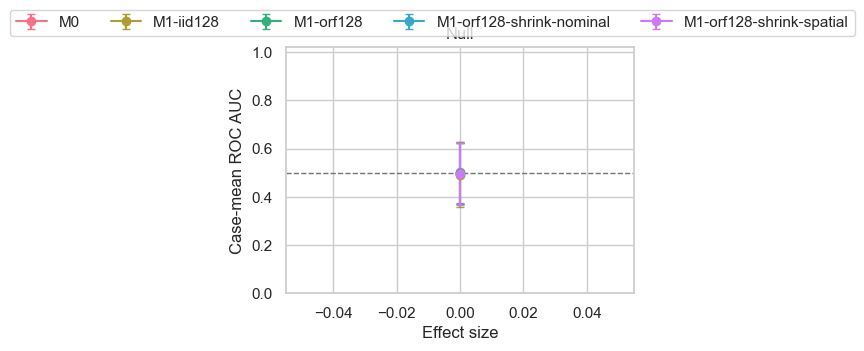

,count,mean,std,distance_from_chance
method,,,,
M0,8.000,0.501,0.153,0.001
M1-iid128,8.000,0.491,0.162,-0.009
M1-orf128,8.000,0.498,0.152,-0.002
M1-orf128-shrink-nominal,8.000,0.498,0.152,-0.002
M1-orf128-shrink-spatial,8.000,0.495,0.154,-0.005


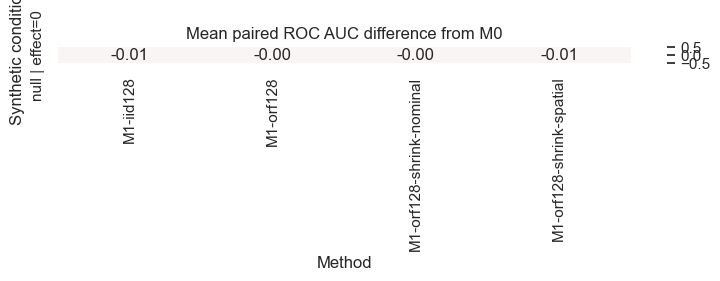

In [7]:
signal = case_scores[case_scores['experiment_family'].isin(['null_control', 'signal_recovery'])]
scenarios = list(dict.fromkeys(signal['scenario']))
if not scenarios:
    display(Markdown('No null or signal-recovery cases were loaded.'))
else:
    ncols = min(3, len(scenarios))
    nrows = int(np.ceil(len(scenarios) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.5 * nrows), squeeze=False)
    for ax, scenario_name in zip(axes.flat, scenarios):
        subset = signal[signal['scenario'] == scenario_name]
        for method in method_order:
            method_data = subset[subset['method'] == method]
            if method_data.empty:
                continue
            stats = method_data.groupby('effect_size')['auc'].agg(['mean', 'count']).reset_index()
            error = (
                method_data.groupby('effect_size')['auc']
                .apply(interval_half_width)
                .reindex(stats['effect_size'])
                .to_numpy()
            )
            ax.errorbar(
                stats['effect_size'], stats['mean'], yerr=error,
                marker='o', capsize=3, label=method, color=palette[method],
            )
        ax.axhline(0.5, color='0.45', linewidth=1, linestyle='--')
        ax.set(title=scenario_name.replace('_', ' ').title(), xlabel='Effect size', ylabel='Case-mean ROC AUC')
        ax.set_ylim(0.0, 1.02)
    for ax in axes.flat[len(scenarios):]:
        ax.set_visible(False)
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=min(5, len(labels)))
    plt.tight_layout()
    plt.show()

null_scores = case_scores[case_scores['experiment_family'] == 'null_control']
if null_scores.empty:
    display(Markdown('**Null control not included in this mode.** This is expected for smoke mode.'))
else:
    null_summary = null_scores.groupby('method')['auc'].agg(['count', 'mean', 'std']).reindex(method_order)
    null_summary['distance_from_chance'] = null_summary['mean'] - 0.5
    display(null_summary.style.format('{:.3f}', na_rep='—'))

paired_signal = comparison[
    comparison['experiment_family'].isin(['null_control', 'signal_recovery'])
    & (comparison['method'] != 'M0')
].copy()
if not paired_signal.empty:
    paired_signal['condition'] = (
        paired_signal['scenario'] + ' | effect=' + paired_signal['effect_size'].map(lambda value: f'{value:g}')
    )
    heatmap = paired_signal.pivot_table(
        index='condition', columns='method', values='mean_delta_auc', aggfunc='mean'
    ).reindex(columns=[method for method in method_order if method != 'M0'])
    plt.figure(figsize=(max(8, 1.05 * len(heatmap.columns)), max(2.8, 0.48 * len(heatmap))))
    sns.heatmap(heatmap, annot=True, fmt='.2f', center=0.0, vmin=-0.5, vmax=0.5, cmap='vlag')
    plt.title('Mean paired ROC AUC difference from M0')
    plt.xlabel('Method')
    plt.ylabel('Synthetic condition')
    plt.tight_layout()
    plt.show()

## 6. Bag size, spatial dependence, and unequal bags

These experiment families are kept separate. Declining performance for small or unequal bags points toward embedding shrinkage. Declining performance with spatial range measures sensitivity to reduced effective information, not a change in the marginal distribution.

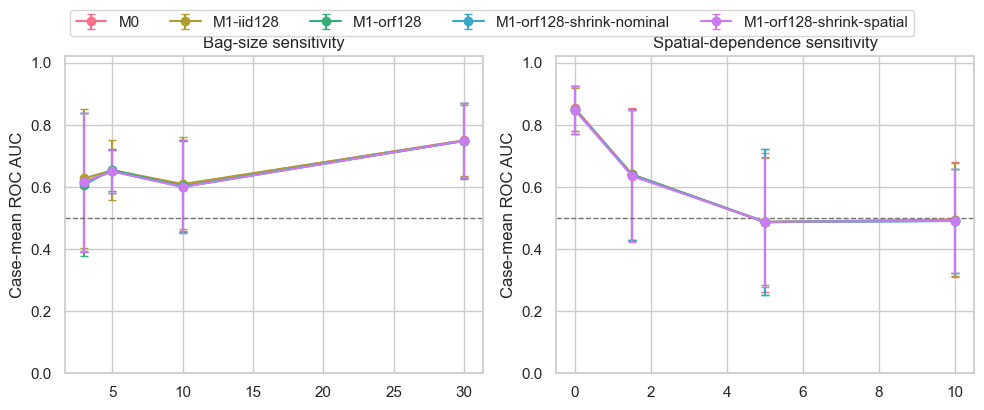

In [8]:
nuisance_families = [
    ('bag_size_sensitivity', 'bag_size', 'Bag-size sensitivity'),
    ('spatial_dependence', 'spatial_range', 'Spatial-dependence sensitivity'),
    ('unequal_bags', None, 'Unequal-bag robustness'),
]
available_families = [item for item in nuisance_families if item[0] in set(case_scores['experiment_family'])]
if not available_families:
    display(Markdown('No nuisance-condition cases were loaded. This is expected for smoke mode.'))
else:
    fig, axes = plt.subplots(1, len(available_families), figsize=(5.0 * len(available_families), 4), squeeze=False)
    for ax, (family, x_column, title) in zip(axes.flat, available_families):
        subset = case_scores[case_scores['experiment_family'] == family]
        if x_column is None:
            sns.boxplot(data=subset, x='method', y='auc', order=method_order, ax=ax)
            sns.stripplot(data=subset, x='method', y='auc', order=method_order, color='0.25', size=3, ax=ax)
            ax.tick_params(axis='x', rotation=55)
        else:
            for method in method_order:
                method_data = subset[subset['method'] == method]
                stats = method_data.groupby(x_column)['auc'].agg(['mean', 'count']).reset_index()
                error = (
                    method_data.groupby(x_column)['auc']
                    .apply(interval_half_width)
                    .reindex(stats[x_column])
                    .to_numpy()
                )
                ax.errorbar(
                    stats[x_column], stats['mean'], yerr=error,
                    marker='o', capsize=3, label=method, color=palette[method],
                )
        ax.axhline(0.5, color='0.45', linewidth=1, linestyle='--')
        ax.set_title(title)
        ax.set_ylabel('Case-mean ROC AUC')
        ax.set_ylim(0.0, 1.02)
    if any(item[1] is not None for item in available_families):
        handles, labels = axes.flat[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.04), ncol=min(5, len(labels)))
    plt.tight_layout()
    plt.show()

## 7. Representation approximation fidelity

M1 is primarily judged as a scalable approximation to M0. Compare IID and orthogonal random features at the same feature budget; lower kernel and population-embedding error is better. Shrinkage is intended to reduce small-bag estimation error, not automatically maximize AUC. The displayed thresholds—relative kernel error at most 0.10 and score Spearman correlation at least 0.95—are practical diagnostics, not formal statistical guarantees.

,method,rff_features,rff_scheme,embedding_estimator,n_cases,relative_kernel_error,maximum_kernel_error,kernel_correlation,score_spearman,minimum_score_spearman,top_5_overlap,diagnostic_status
0,M1-iid128,128,iid,empirical,40,0.029,0.042,0.990,0.978,0.930,86.9%,PRACTICAL; REVIEW TAILS
1,M1-orf128,128,orthogonal,empirical,40,0.035,0.040,0.998,0.981,0.949,93.1%,PRACTICAL; REVIEW TAILS
2,M1-orf128-shrink-nominal,128,orthogonal,shrinkage,40,0.130,0.408,0.983,0.980,0.942,93.1%,REVIEW
3,M1-orf128-shrink-spatial,128,orthogonal,shrinkage,40,0.229,0.408,0.961,0.978,0.928,91.2%,REVIEW


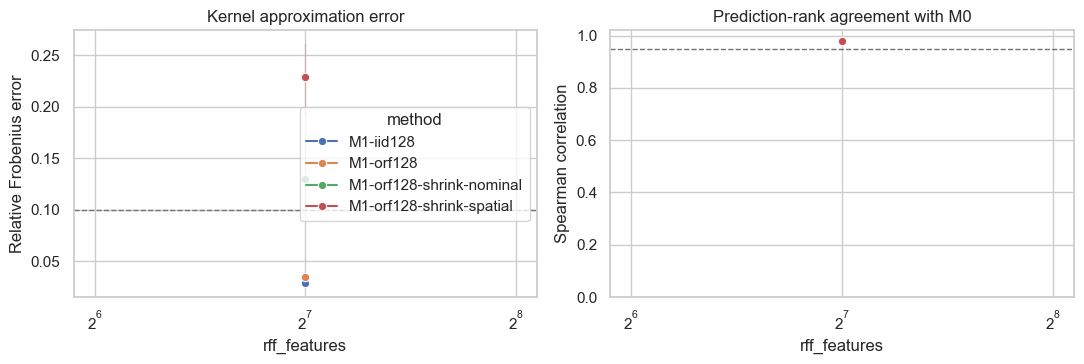

In [9]:
rff_details = {
    item.get('id', item['method']): {
        'rff_features': item.get('rff_features'),
        'rff_scheme': item.get('rff_scheme', 'iid'),
        'embedding_estimator': item.get('embedding_estimator', 'empirical'),
    }
    for item in configuration['methods'] if item['method'] == 'M1'
}
m1_rows = []
for case in result['cases']:
    case_index = int(case['case_id'].split('-', 2)[1])
    metadata = metadata_by_index[case_index]
    for row in case['fold_results']:
        approximation = row.get('diagnostics', {}).get('kernel_approximation')
        agreement = row.get('diagnostics', {}).get('score_agreement_with_M0')
        if approximation and agreement:
            m1_rows.append({
                'case_id': case['case_id'],
                'experiment_family': metadata['experiment_family'],
                'method': row['method'],
                **rff_details.get(row['method'], {}),
                **approximation,
                **{f'score_{key}': value for key, value in agreement.items()},
            })

m1_folds = pd.DataFrame(m1_rows)
if m1_folds.empty:
    display(Markdown('No M1 approximation diagnostics were recorded.'))
    m1_summary = pd.DataFrame()
else:
    m1_cases = (
        m1_folds.groupby(
            ['case_id', 'method', 'rff_features', 'rff_scheme', 'embedding_estimator'],
            dropna=False,
        )
        .mean(numeric_only=True)
        .reset_index()
    )
    m1_summary = (
        m1_cases.groupby(
            ['method', 'rff_features', 'rff_scheme', 'embedding_estimator'],
            dropna=False,
        )
        .agg(
            n_cases=('case_id', 'nunique'),
            relative_kernel_error=('relative_frobenius_error', 'mean'),
            maximum_kernel_error=('relative_frobenius_error', 'max'),
            kernel_correlation=('upper_triangle_correlation', 'mean'),
            score_spearman=('score_spearman', 'mean'),
            minimum_score_spearman=('score_spearman', 'min'),
            top_5_overlap=('score_top_5_percent_overlap', 'mean'),
        )
        .reset_index()
    )
    mean_fidelity = (
        (m1_summary['relative_kernel_error'] <= 0.10)
        & (m1_summary['score_spearman'] >= 0.95)
    )
    worst_case_fidelity = (
        (m1_summary['maximum_kernel_error'] <= 0.10)
        & (m1_summary['minimum_score_spearman'] >= 0.95)
    )
    m1_summary['diagnostic_status'] = np.select(
        [mean_fidelity & worst_case_fidelity, mean_fidelity],
        ['HIGH FIDELITY', 'PRACTICAL; REVIEW TAILS'],
        default='REVIEW',
    )
    display(m1_summary.style.format({
        'relative_kernel_error': '{:.3f}',
        'maximum_kernel_error': '{:.3f}',
        'kernel_correlation': '{:.3f}',
        'score_spearman': '{:.3f}',
        'minimum_score_spearman': '{:.3f}',
        'top_5_overlap': '{:.1%}',
    }))

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    sns.lineplot(
        data=m1_cases, x='rff_features', y='relative_frobenius_error',
        hue='method', marker='o', ax=axes[0],
    )
    axes[0].axhline(0.10, color='0.45', linestyle='--', linewidth=1)
    axes[0].set(title='Kernel approximation error', ylabel='Relative Frobenius error')
    sns.lineplot(
        data=m1_cases, x='rff_features', y='score_spearman',
        hue='method', marker='o', ax=axes[1], legend=False,
    )
    axes[1].axhline(0.95, color='0.45', linestyle='--', linewidth=1)
    axes[1].set(title='Prediction-rank agreement with M0', ylabel='Spearman correlation', ylim=(0, 1.02))
    for ax in axes:
        ax.set_xscale('log', base=2)
    plt.tight_layout()
    plt.show()

### 7.1 ORF, shrinkage, and M4 diagnostics

These diagnostics answer three separate questions. **Embedding MSE** compares each observed-bag embedding with an independent large reference bag from the same known synthetic distribution. **Shrinkage factor** shows how strongly a noisy empirical embedding is pulled toward zero (1 means no shrinkage). **Selected M4 weight** is chosen using inner validation inside each outer training fold: 1 favors the mean-embedding component, 0 favors sliced Wasserstein. Interpret a weight as scenario evidence, not as a universal mixture.

,n_cases,mean_embedding_mse,median_embedding_mse,mean_shrinkage_factor,mean_effective_sample_size,rff_cache_hit_rate,median_rff_initialization_seconds,mean_selected_hybrid_weight
method,,,,,,,,
M1-iid128,40,0.1032,0.07922,1.000,22.80,—,0.000585,—
M1-orf128,40,0.1116,0.08605,1.000,22.80,99.4%,0.000917,—
M1-orf128-shrink-nominal,40,0.108,0.08159,0.946,22.80,100.0%,0.000958,—
M1-orf128-shrink-spatial,40,0.09329,0.07744,0.890,11.71,100.0%,0.000941,—


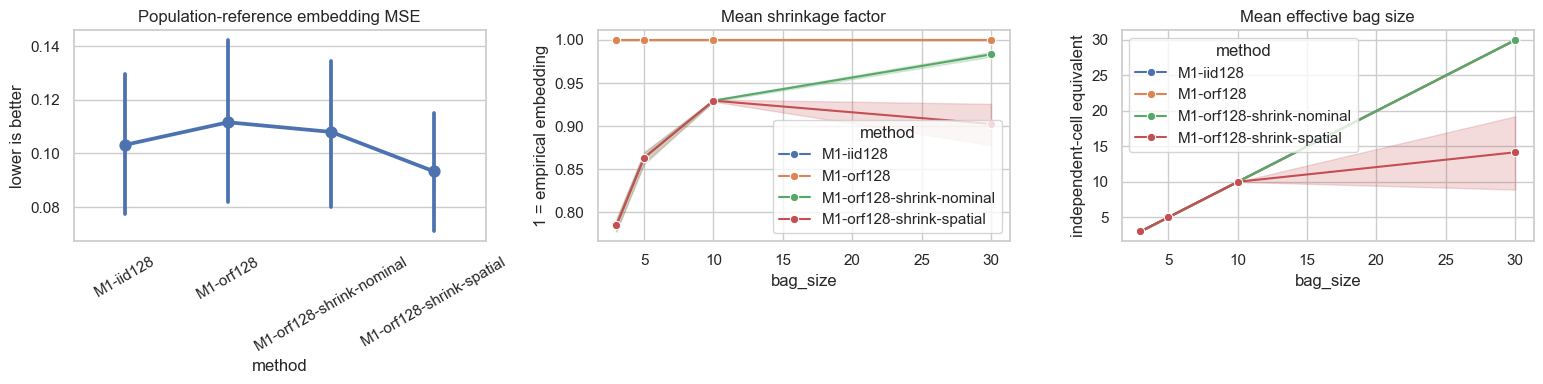

**Decision rule:** retain ORF if it lowers approximation error at the same feature count; retain shrinkage if it lowers reference-embedding MSE for small or dependent bags without damaging larger bags; retain M4 only if inner-selected weights and outer-fold gains repeat within distributional scenarios. AUC alone does not establish any of these claims.

In [10]:
extension_rows = []
for row in folds.to_dict(orient='records'):
    diagnostics = row.get('diagnostics') or {}
    extension_rows.append({
        'case_id': row['case_id'],
        'scenario': row['scenario'],
        'bag_size': row['bag_size'],
        'spatial_range': row['spatial_range'],
        'method': row['method'],
        'embedding_mse': row.get('embedding_mse'),
        'mean_shrinkage_factor': diagnostics.get('mean_shrinkage_factor'),
        'mean_effective_sample_size': diagnostics.get('mean_effective_sample_size'),
        'rff_frequency_cache_hit': diagnostics.get('rff_frequency_cache_hit'),
        'rff_frequency_initialization_seconds': diagnostics.get('rff_frequency_initialization_seconds'),
        'selected_hybrid_weight': diagnostics.get('hybrid_weight'),
    })
extension_folds = pd.DataFrame(extension_rows)
extension_cases = (
    extension_folds.groupby(
        ['case_id', 'scenario', 'bag_size', 'spatial_range', 'method'], dropna=False
    )
    .agg(
        embedding_mse=('embedding_mse', 'mean'),
        mean_shrinkage_factor=('mean_shrinkage_factor', 'mean'),
        mean_effective_sample_size=('mean_effective_sample_size', 'mean'),
        rff_frequency_cache_hit=('rff_frequency_cache_hit', 'mean'),
        rff_frequency_initialization_seconds=('rff_frequency_initialization_seconds', 'median'),
        selected_hybrid_weight=('selected_hybrid_weight', 'mean'),
    )
    .reset_index()
)
extension_summary = (
    extension_cases.groupby('method', dropna=False)
    .agg(
        n_cases=('case_id', 'nunique'),
        mean_embedding_mse=('embedding_mse', 'mean'),
        median_embedding_mse=('embedding_mse', 'median'),
        mean_shrinkage_factor=('mean_shrinkage_factor', 'mean'),
        mean_effective_sample_size=('mean_effective_sample_size', 'mean'),
        rff_cache_hit_rate=('rff_frequency_cache_hit', 'mean'),
        median_rff_initialization_seconds=('rff_frequency_initialization_seconds', 'median'),
        mean_selected_hybrid_weight=('selected_hybrid_weight', 'mean'),
    )
    .dropna(how='all', subset=[
        'mean_embedding_mse', 'mean_shrinkage_factor', 'mean_effective_sample_size',
        'rff_cache_hit_rate', 'median_rff_initialization_seconds',
        'mean_selected_hybrid_weight'
    ])
)
if extension_summary.empty:
    display(Markdown('This result predates the representation-extension diagnostics.'))
else:
    display(extension_summary.style.format({
        'mean_embedding_mse': '{:.4g}',
        'median_embedding_mse': '{:.4g}',
        'mean_shrinkage_factor': '{:.3f}',
        'mean_effective_sample_size': '{:.2f}',
        'rff_cache_hit_rate': '{:.1%}',
        'median_rff_initialization_seconds': '{:.6f}',
        'mean_selected_hybrid_weight': '{:.2f}',
    }, na_rep='—'))

    figure_data = [
        ('embedding_mse', 'Population-reference embedding MSE', 'lower is better'),
        ('mean_shrinkage_factor', 'Mean shrinkage factor', '1 = empirical embedding'),
        ('mean_effective_sample_size', 'Mean effective bag size', 'independent-cell equivalent'),
        ('selected_hybrid_weight', 'M4 selected mean-kernel weight', '0 = SW; 1 = mean embedding'),
    ]
    available = [item for item in figure_data if extension_cases[item[0]].notna().any()]
    fig, axes = plt.subplots(1, len(available), figsize=(5.2 * len(available), 4), squeeze=False)
    for ax, (column, title, ylabel) in zip(axes[0], available):
        subset = extension_cases.dropna(subset=[column])
        if column in {'mean_shrinkage_factor', 'mean_effective_sample_size'}:
            sns.lineplot(data=subset, x='bag_size', y=column, hue='method', marker='o', ax=ax)
        elif column == 'selected_hybrid_weight':
            sns.stripplot(data=subset, x='scenario', y=column, color='0.25', jitter=0.12, ax=ax)
            ax.tick_params(axis='x', rotation=30)
        else:
            sns.pointplot(data=subset, x='method', y=column, errorbar=('ci', 95), ax=ax)
            ax.tick_params(axis='x', rotation=30)
        ax.set(title=title, ylabel=ylabel)
    plt.tight_layout()
    plt.show()

display(Markdown(
    '**Decision rule:** retain ORF if it lowers approximation error at the same feature count; '
    'retain shrinkage if it lowers reference-embedding MSE for small or dependent bags without '
    'damaging larger bags; retain M4 only if inner-selected weights and outer-fold gains repeat '
    'within distributional scenarios. AUC alone does not establish any of these claims.'
))

### 7.2 Focused spatial-shrinkage and ORF-cache gate

This section is populated by **spatial_shrinkage** mode. It checks whether coordinate-derived effective sample size responds coherently to dependence, whether that correction improves population-reference embedding error relative to nominal shrinkage, and whether repeated ORF construction reuses the same bandwidth-free frequency draw.

,spatial_range,method,n_cases,mean_effective_sample_size,mean_shrinkage_factor,mean_embedding_mse
0,0.000000,M1-orf128-shrink-nominal,8,30.00,0.976,0.01487
1,0.000000,M1-orf128-shrink-spatial,8,30.00,0.976,0.01487
2,1.500000,M1-orf128-shrink-nominal,4,30.00,0.982,0.0832
3,1.500000,M1-orf128-shrink-spatial,4,4.44,0.877,0.07725
4,5.000000,M1-orf128-shrink-nominal,4,30.00,0.991,0.2205
5,5.000000,M1-orf128-shrink-spatial,4,1.69,0.838,0.1792
6,10.000000,M1-orf128-shrink-nominal,4,30.00,0.994,0.2859
7,10.000000,M1-orf128-shrink-spatial,4,1.31,0.864,0.2296


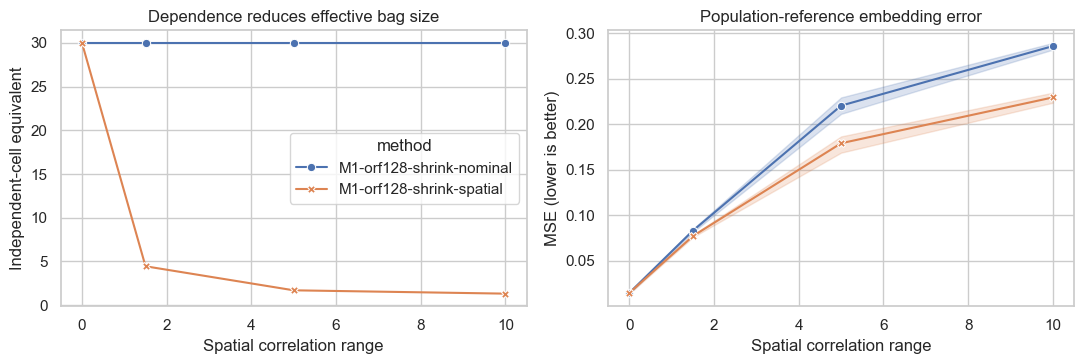

**Paired embedding error:** negative values favor spatial ESS.

,scenario,bag_size,spatial_range,n_cases,mean_delta_mse,median_delta_mse
0,mean_shift,3,0.000000,4,+0,+0
1,mean_shift,5,0.000000,4,+0,+0
2,mean_shift,10,0.000000,4,+0,+0
3,mean_shift,30,0.000000,8,+0,+0
4,mean_shift,30,1.500000,4,-0.005948,-0.00598
5,mean_shift,30,5.000000,4,-0.0413,-0.04108
6,mean_shift,30,10.000000,4,-0.05639,-0.05655
7,null,30,0.000000,4,+0,+0
8,null,30,5.000000,4,-0.04366,-0.04301


**ORF frequency construction cache**

,initializations,median_seconds,maximum_seconds
cache_state,,,
constructed,1,1.053290,1.053290
reused,479,0.000915,0.001932


,gate,status,evidence,meaning
0,Independent limit,PASS,range 0 effective size = 30.00 of 30,"With no spatial correlation, coordinate ESS mu..."
1,Dependence response,PASS,"0: 30.00, 1.5: 4.44, 5: 1.69, 10: 1.31",Stronger assumed correlation must reduce indep...
2,Spatial shrinkage MSE,IMPROVES,mean paired spatial − nominal MSE at positive ...,This is the representation-level decision stat...
3,ORF cache reuse,PASS,constructed=1; reused=479,Repeated folds reuse one seed/dimension/featur...


In [11]:
spatial_methods = [
    'M1-orf128-shrink-nominal',
    'M1-orf128-shrink-spatial',
]
spatial_cases = extension_cases[extension_cases['method'].isin(spatial_methods)].copy()
spatial_gates = []
if LAB_MODE != 'spatial_shrinkage' or spatial_cases.empty:
    display(Markdown('Run `LAB_MODE = \'spatial_shrinkage\'` to populate this focused gate.'))
else:
    bag30 = spatial_cases[
        (spatial_cases['scenario'] == 'mean_shift')
        & (spatial_cases['bag_size'] == 30)
    ]
    diagnostic_summary = (
        bag30.groupby(['spatial_range', 'method'])
        .agg(
            n_cases=('case_id', 'nunique'),
            mean_effective_sample_size=('mean_effective_sample_size', 'mean'),
            mean_shrinkage_factor=('mean_shrinkage_factor', 'mean'),
            mean_embedding_mse=('embedding_mse', 'mean'),
        )
        .reset_index()
    )
    display(diagnostic_summary.style.format({
        'mean_effective_sample_size': '{:.2f}',
        'mean_shrinkage_factor': '{:.3f}',
        'mean_embedding_mse': '{:.4g}',
    }))

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    sns.lineplot(
        data=diagnostic_summary, x='spatial_range', y='mean_effective_sample_size',
        hue='method', style='method', markers=True, dashes=False, ax=axes[0],
    )
    axes[0].set(
        title='Dependence reduces effective bag size',
        xlabel='Spatial correlation range',
        ylabel='Independent-cell equivalent',
    )
    sns.lineplot(
        data=bag30, x='spatial_range', y='embedding_mse',
        hue='method', style='method', markers=True, dashes=False,
        errorbar=('ci', 95), ax=axes[1], legend=False,
    )
    axes[1].set(
        title='Population-reference embedding error',
        xlabel='Spatial correlation range', ylabel='MSE (lower is better)',
    )
    plt.tight_layout()
    plt.show()

    paired_mse = (
        spatial_cases.pivot_table(
            index=['case_id', 'scenario', 'bag_size', 'spatial_range'],
            columns='method', values='embedding_mse', aggfunc='mean',
        )
        .dropna(subset=spatial_methods)
        .reset_index()
    )
    paired_mse['spatial_minus_nominal_mse'] = (
        paired_mse[spatial_methods[1]] - paired_mse[spatial_methods[0]]
    )
    mse_summary = (
        paired_mse.groupby(['scenario', 'bag_size', 'spatial_range'])
        .agg(
            n_cases=('case_id', 'nunique'),
            mean_delta_mse=('spatial_minus_nominal_mse', 'mean'),
            median_delta_mse=('spatial_minus_nominal_mse', 'median'),
        )
        .reset_index()
    )
    display(Markdown('**Paired embedding error:** negative values favor spatial ESS.'))
    display(mse_summary.style.format({
        'mean_delta_mse': '{:+.4g}', 'median_delta_mse': '{:+.4g}',
    }))

    spatial_ess = (
        bag30[bag30['method'] == spatial_methods[1]]
        .groupby('spatial_range')['mean_effective_sample_size'].mean()
        .sort_index()
    )
    zero_ess_ok = bool(
        0.0 in spatial_ess.index and np.isclose(spatial_ess.loc[0.0], 30.0, atol=1e-6)
    )
    dependence_ok = bool(
        len(spatial_ess) > 1
        and np.all(np.diff(spatial_ess.to_numpy()) <= 1e-8)
        and spatial_ess.iloc[-1] < spatial_ess.iloc[0]
    )
    positive_range = paired_mse[paired_mse['spatial_range'] > 0]
    mean_delta = float(positive_range['spatial_minus_nominal_mse'].mean())
    spatial_gates.extend([
        {
            'gate': 'Independent limit',
            'status': 'PASS' if zero_ess_ok else 'FAIL',
            'evidence': f'range 0 effective size = {spatial_ess.get(0.0, np.nan):.2f} of 30',
            'meaning': 'With no spatial correlation, coordinate ESS must equal the unique-cell count.',
        },
        {
            'gate': 'Dependence response',
            'status': 'PASS' if dependence_ok else 'FAIL',
            'evidence': ', '.join(f'{value:g}: {ess:.2f}' for value, ess in spatial_ess.items()),
            'meaning': 'Stronger assumed correlation must reduce independent-cell information.',
        },
        {
            'gate': 'Spatial shrinkage MSE',
            'status': 'IMPROVES' if mean_delta < 0 else 'REVIEW',
            'evidence': f'mean paired spatial − nominal MSE at positive ranges = {mean_delta:+.4g}',
            'meaning': 'This is the representation-level decision statistic; predictive metrics are secondary.',
        },
    ])

    cache_rows = extension_folds.dropna(
        subset=['rff_frequency_cache_hit', 'rff_frequency_initialization_seconds']
    ).copy()
    if not cache_rows.empty:
        cache_rows['cache_state'] = np.where(
            cache_rows['rff_frequency_cache_hit'].astype(bool), 'reused', 'constructed'
        )
        cache_summary = (
            cache_rows.groupby('cache_state')
            .agg(
                initializations=('case_id', 'size'),
                median_seconds=('rff_frequency_initialization_seconds', 'median'),
                maximum_seconds=('rff_frequency_initialization_seconds', 'max'),
            )
        )
        display(Markdown('**ORF frequency construction cache**'))
        display(cache_summary.style.format({
            'median_seconds': '{:.6f}', 'maximum_seconds': '{:.6f}',
        }))
        cache_ok = {'constructed', 'reused'}.issubset(set(cache_summary.index))
        spatial_gates.append({
            'gate': 'ORF cache reuse',
            'status': 'PASS' if cache_ok else 'REVIEW',
            'evidence': '; '.join(
                f'{state}={int(row.initializations)}'
                for state, row in cache_summary.iterrows()
            ),
            'meaning': 'Repeated folds reuse one seed/dimension/feature draw; sigma remains fold-specific.',
        })
    display(pd.DataFrame(spatial_gates))


## 8. Distribution invariance checks

Cell order and uniform duplication should not change predictions beyond numerical precision. Selectively duplicating cells changes empirical probability mass and is therefore expected to change predictions. It is reported as sensitivity, not scored as pass or fail.

In [12]:
invariance_rows = []
for case in result['cases']:
    for method, values in (case.get('invariance') or {}).items():
        invariance_rows.append({
            'case_id': case['case_id'],
            'method': method,
            'permutation_change': values['permuted_maximum_absolute_score_change'],
            'uniform_duplication_change': values['uniformly_duplicated_maximum_absolute_score_change'],
            'selective_duplication_change': values['selectively_duplicated_maximum_absolute_score_change'],
        })
invariance = pd.DataFrame(invariance_rows)
if invariance.empty:
    display(Markdown('Invariance checks were disabled in this configuration. The smoke run is the required invariance gate.'))
    invariance_pass = None
else:
    invariance_summary = invariance.groupby('method').agg(
        maximum_permutation_change=('permutation_change', 'max'),
        maximum_uniform_duplication_change=('uniform_duplication_change', 'max'),
        median_selective_duplication_change=('selective_duplication_change', 'median'),
    ).reindex([method for method in method_order if method in set(invariance['method'])])
    invariance_summary['invariance_status'] = np.where(
        (invariance_summary['maximum_permutation_change'] <= 1e-5)
        & (invariance_summary['maximum_uniform_duplication_change'] <= 1e-5),
        'PASS',
        'FAIL',
    )
    invariance_pass = bool((invariance_summary['invariance_status'] == 'PASS').all())
    display(invariance_summary.style.format({
        'maximum_permutation_change': '{:.2e}',
        'maximum_uniform_duplication_change': '{:.2e}',
        'median_selective_duplication_change': '{:.3f}',
    }))

Invariance checks were disabled in this configuration. The smoke run is the required invariance gate.

## 9. Computational diagnostics

Timing is descriptive. The first fold can include JAX tracing and compilation, while new bag shapes may trigger later compilations. Use later-fold medians as a better—but still approximate—steady-state comparison. Dedicated scaling benchmarks remain necessary for speed claims.

In [13]:
first_fold_mask = (folds['repeat'] == 1) & (folds['fold'] == 1)
timing_all = folds.groupby('method').agg(
    median_fit_seconds=('fit_seconds', 'median'),
    median_predict_seconds=('predict_seconds', 'median'),
    median_peak_python_mb=('peak_python_memory_mb', 'median'),
)
first_timing = folds[first_fold_mask].groupby('method')['fit_seconds'].median().rename('first_fold_fit_seconds')
later_timing = folds[~first_fold_mask].groupby('method')['fit_seconds'].median().rename('later_fold_fit_seconds')
timing = timing_all.join(first_timing).join(later_timing).reindex(method_order)
display(timing.style.format('{:.4f}', na_rep='—'))

,median_fit_seconds,median_predict_seconds,median_peak_python_mb,first_fold_fit_seconds,later_fold_fit_seconds
method,,,,,
M0,0.0732,0.0215,0.4145,0.0741,0.0729
M1-iid128,0.0674,0.0186,0.4688,0.0699,0.0665
M1-orf128,0.0672,0.0186,0.4717,0.0678,0.0670
M1-orf128-shrink-nominal,0.0838,0.0244,0.4762,0.0839,0.0838
M1-orf128-shrink-spatial,0.0985,0.0299,0.5641,0.1009,0.0975


## 10. Automated interpretation and extension gate

The table below identifies evidence and limitations; it deliberately avoids declaring a universal winner. A method earns further consideration when it improves on the same cases as M0, generalizes, and repeats across independently generated datasets.

In [14]:
findings = []
integrity_pass = bool((integrity_checks['status'] == 'PASS').all())
findings.append({
    'gate': 'Execution integrity',
    'status': 'PASS' if integrity_pass else 'FAIL',
    'evidence': f"{len(result['cases'])} cases; {len(folds)} fold-method rows",
    'meaning': 'Interpret results only if all integrity checks pass.',
})
findings.append({
    'gate': 'Scientific scope',
    'status': 'DIAGNOSTIC ONLY' if LAB_MODE in {'smoke', 'extensions_smoke'} else 'RESEARCH SUITE',
    'evidence': f"{len(result['cases'])} independently generated cases",
    'meaning': 'Smoke modes validate software; replicated modes support methodological interpretation.',
})
boyce_fraction = float(metric_rows['boyce'].notna().mean())
findings.append({
    'gate': 'Presence-only metrics',
    'status': 'REVIEW' if boyce_fraction < 0.5 or top_count == 1 else 'USABLE',
    'evidence': f"Boyce defined {boyce_fraction:.0%}; top 5% selects {top_count}–{top_count_max} bag(s)",
    'meaning': 'Prefer AUC and PR AUC when Boyce is sparse or lift is discrete.',
})
if not m1_summary.empty:
    for row in m1_summary.itertuples():
        findings.append({
            'gate': f'M1 fidelity: {row.method}',
            'status': row.diagnostic_status,
            'evidence': f"features={int(row.rff_features)}, mean/max error={row.relative_kernel_error:.3f}/{row.maximum_kernel_error:.3f}, mean/min rank={row.score_spearman:.3f}/{row.minimum_score_spearman:.3f}",
            'meaning': 'Review each feature budget separately; one low-budget variant must not fail the whole M1 family.',
        })
if invariance_pass is not None:
    findings.append({
        'gate': 'Distribution invariance',
        'status': 'PASS' if invariance_pass else 'FAIL',
        'evidence': 'Permutation and uniform-duplication tolerance = 1e-5',
        'meaning': 'Selective duplication is intentionally excluded because it changes probability mass.',
    })
if not extension_summary.empty and extension_cases['embedding_mse'].notna().any():
    embedding_means = (
        extension_cases.dropna(subset=['embedding_mse'])
        .groupby('method')['embedding_mse'].mean()
        .sort_values()
    )
    findings.append({
        'gate': 'Population-reference embedding error',
        'status': 'DIAGNOSTIC' if LAB_MODE == 'extensions_smoke' else 'REVIEW',
        'evidence': '; '.join(f'{method}={value:.4g}' for method, value in embedding_means.items()),
        'meaning': 'Compare schemes at equal feature budgets and shrinkage within the same scenarios.',
    })
if not extension_summary.empty and extension_cases['selected_hybrid_weight'].notna().any():
    weights = extension_cases['selected_hybrid_weight'].dropna()
    findings.append({
        'gate': 'M4 inner selection',
        'status': 'VARIABLE' if weights.nunique() > 1 else 'FIXED',
        'evidence': f'selected weights={sorted(weights.unique().tolist())}',
        'meaning': 'Variation is coherent only if it repeats by scenario in the replicated extension suite.',
    })
if spatial_gates:
    findings.extend(spatial_gates)
if not null_scores.empty:
    null_deviation = null_scores.groupby('method')['auc'].mean().sub(0.5).abs()
    findings.append({
        'gate': 'Null behavior',
        'status': 'CONSISTENT' if null_deviation.max() <= 0.15 else 'REVIEW',
        'evidence': f"largest mean distance from chance = {null_deviation.max():.3f}",
        'meaning': 'Systematic null performance away from 0.5 suggests leakage, bias, or too few replicates.',
    })

robust_gains = comparison[
    (comparison['method'] != 'M0')
    & (comparison['n_cases'] >= 2)
    & (comparison['mean_delta_auc'] > 0.02)
    & (comparison['delta_ci_low'] > 0)
]
if LAB_MODE not in {'smoke', 'extensions_smoke'}:
    if robust_gains.empty:
        gain_evidence = 'No paired gain above 0.02 has a replicate-level interval entirely above zero.'
        gain_status = 'NO CLEAR GAIN'
    else:
        gain_evidence = '; '.join(
            f"{row.scenario}/{row.method}: ΔAUC={row.mean_delta_auc:.3f}"
            for row in robust_gains.sort_values('mean_delta_auc', ascending=False).head(6).itertuples()
        )
        gain_status = 'CANDIDATES'
    findings.append({
        'gate': 'Replicated gains over M0',
        'status': gain_status,
        'evidence': gain_evidence,
        'meaning': 'Candidates still require scenario coherence and acceptable generalization gaps.',
    })
display(pd.DataFrame(findings))

extension_guide = pd.DataFrame([
    {'Observed pattern': 'ORF lowers error at the same feature budget', 'Next extension': 'Retain ORF for empirical validation'},
    {'Observed pattern': 'Shrinkage lowers small-bag embedding MSE without a large-bag penalty', 'Next extension': 'Retain shrinkage for empirical validation'},
    {'Observed pattern': 'Sparse-signal cases trail comparable low-dimensional cases', 'Next extension': 'ARD or grouped kernels'},
    {'Observed pattern': 'M2 repeatedly improves nonlinear-mixture cases without a large gap', 'Next extension': 'Continue nonlinear bag-level kernels'},
    {'Observed pattern': 'M4 selects stable scenario-specific weights and improves outer-fold scores', 'Next extension': 'Retain experimental hybrid for empirical validation'},
])
display(Markdown('### How findings select the next methods sprint'))
display(extension_guide)

,gate,status,evidence,meaning
0,Execution integrity,PASS,40 cases; 800 fold-method rows,Interpret results only if all integrity checks...
1,Scientific scope,RESEARCH SUITE,40 independently generated cases,Smoke modes validate software; replicated mode...
2,Presence-only metrics,USABLE,Boyce defined 100%; top 5% selects 3–3 bag(s),Prefer AUC and PR AUC when Boyce is sparse or ...
3,M1 fidelity: M1-iid128,PRACTICAL; REVIEW TAILS,"features=128, mean/max error=0.029/0.042, mean...",Review each feature budget separately; one low...
4,M1 fidelity: M1-orf128,PRACTICAL; REVIEW TAILS,"features=128, mean/max error=0.035/0.040, mean...",Review each feature budget separately; one low...
5,M1 fidelity: M1-orf128-shrink-nominal,REVIEW,"features=128, mean/max error=0.130/0.408, mean...",Review each feature budget separately; one low...
6,M1 fidelity: M1-orf128-shrink-spatial,REVIEW,"features=128, mean/max error=0.229/0.408, mean...",Review each feature budget separately; one low...
7,Population-reference embedding error,REVIEW,M1-orf128-shrink-spatial=0.09329; M1-iid128=0....,Compare schemes at equal feature budgets and s...
8,Independent limit,PASS,range 0 effective size = 30.00 of 30,"With no spatial correlation, coordinate ESS mu..."
9,Dependence response,PASS,"0: 30.00, 1.5: 4.44, 5: 1.69, 10: 1.31",Stronger assumed correlation must reduce indep...


### How findings select the next methods sprint

,Observed pattern,Next extension
0,ORF lowers error at the same feature budget,Retain ORF for empirical validation
1,Shrinkage lowers small-bag embedding MSE witho...,Retain shrinkage for empirical validation
2,Sparse-signal cases trail comparable low-dimen...,ARD or grouped kernels
3,M2 repeatedly improves nonlinear-mixture cases...,Continue nonlinear bag-level kernels
4,M4 selects stable scenario-specific weights an...,Retain experimental hybrid for empirical valid...


## 11. Advancement checklist

After either smoke run, advance only if execution integrity passes, relevant diagnostics are finite, and invariance passes. Boyce may remain undefined and lift may remain saturated; those are expected consequences of tiny test folds.

Use **core** for the historical 64-case suite and **targeted_v2** for the unresolved nuisance and nonlinear questions. The completed **extensions** run evaluates ORF, nominal shrinkage, and M4. Use **spatial_shrinkage** as the focused follow-up: require the independent-limit and dependence-response gates to pass, then judge coordinate-aware shrinkage by paired embedding MSE rather than AUC alone. Keep RUN_EXPERIMENT set to True for the first run of a mode. After it completes, set it to False while revisiting plots so the expensive models are not rerun.

Do not promote or remove a method based on synthetic performance alone. Use the laboratory to determine whether a method behaves coherently under signals it claims to represent. Review this focused run before adding any extension to the Section 6 notebook.